# Pioreactor — Chemical Sine Wave Reservoir Computing Template
## Yeast Culture Biophysical Readout & Ridge Regression Pipeline

---

### Supported Experiments
- **Glucose** (`data/sine wave encoding/chem/glucose`)
- **Salt (NaCl)** (`data/sine wave encoding/chem/salt`)
- **Nitrogen (Ammonium Sulphate)** (`data/sine wave encoding/chem/nitro`)
- **Sulfur (Magnesium Sulphate)** (`data/sine wave encoding/chem/sulfur`)

---

### Pipeline Overview
1. **[Section 1] Configuration & Ingestion:** Select chemical target (`CHEM_NAME`), load CSVs, auto-detect cycle interval, parse stirring stall/failure logs.
2. **[Section 2] Raw Signal Plotting:** 7-subplot sensor panel with dosing events and **stirring failure warning markers** (saved to `{OUTPUT_DIR}/raw_sensors_timeline.png`).
3. **[Section 3] Composite Sensor Overlay:** Min-max normalized all-in-one plot with dosing pulse waveforms (saved to `{OUTPUT_DIR}/composite_sensor_overlay.png`).
4. **[Section 4] Data Cleaning & Cycle Aggregation:** Cycle-mean windowing and 6-cycle (4-hour wave) baseline decoupling.
5. **[Section 5] Feature Importance Ranking:** Standardized Ridge coefficient ranking of the most sensitive sensory channels.
6. **[Section 6] Multi-Configuration Benchmark:** Evaluation across feature subsets and delay depths.
7. **[Section 7] Delay Embedding Sweep:** Memory depth sweep across $d = 0 \to 4$ (0 to 160 min history).
8. **[Section 8] Readout Reconstruction & Output Export:** Predicted vs actual dosing volume time-series plot and result table export.
9. **[Section 9] Batch Comparison:** Side-by-side performance summary across all 4 chemical datasets.

In [22]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict
import warnings
warnings.filterwarnings('ignore')

# High-res plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

# ─── 1. SELECT TARGET CHEMICAL HERE ──────────────────────────────────────────
# Options: 'glucose', 'nitro', 'salt', 'sulfur'
CHEM_NAME = "nitro"

# Directory setup (with fallback)
BASE_DIR = r"data/sine wave encoding/chem"
if not os.path.exists(BASE_DIR):
    BASE_DIR = r"D:/omnibio/pioreactor/data/sine wave encoding/chem"

CHEM_DIR = os.path.join(BASE_DIR, CHEM_NAME)
OUT_DIR = os.path.join(CHEM_DIR, "results")
os.makedirs(OUT_DIR, exist_ok=True)

ALPHAS = np.logspace(-4, 6, 100)
print(f"Target Chemical Experiment: {CHEM_NAME.upper()}")
print(f"Results will be saved to   : {OUT_DIR}")

Target Chemical Experiment: NITRO
Results will be saved to   : data/sine wave encoding/chem\nitro\results


## Section 1 — Load Data & Parse Stirring Error Logs

In [23]:
def load_latest_csv(folder, pattern):
    files = sorted(glob.glob(os.path.join(folder, pattern)))
    if not files:
        return None
    df = pd.read_csv(files[-1])
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        df = df.sort_values('timestamp')
    return df

df_dosing = load_latest_csv(CHEM_DIR, "dosing_events-*.csv")
df_co2 = load_latest_csv(CHEM_DIR, "co2_readings-*.csv")
df_growth = load_latest_csv(CHEM_DIR, "growth_rates-*.csv")
df_od = load_latest_csv(CHEM_DIR, "od_readings-*.csv")
df_od_filt = load_latest_csv(CHEM_DIR, "od_readings_filtered-*.csv")
df_spec = load_latest_csv(CHEM_DIR, "as7341_spectrum_readings-*.csv")
df_logs = load_latest_csv(CHEM_DIR, "logs-*.csv")

# Filter manual_dosing_control events
dosing_manual = df_dosing[
    (df_dosing['source_of_event'] == 'dosing_automation:manual_dosing_control') &
    (df_dosing['event'] == 'add_media')
].copy()

t0 = dosing_manual['timestamp'].min()
t_max = dosing_manual['timestamp'].max()
CYCLE_MIN = 40.0 # Standard cycle duration for 12h run

# Aggregate micro-doses into cycle volume
dosing_manual['cycle'] = np.round((dosing_manual['timestamp'] - t0).dt.total_seconds() / (CYCLE_MIN * 60.0)).astype(int)
sine_input = dosing_manual.groupby('cycle')['volume_change_ml'].sum()
total_cycles = len(sine_input)
t_end = t0 + pd.Timedelta(minutes=total_cycles * CYCLE_MIN)
u = sine_input.values

# Parse stirring failure / stall logs
stirring_stalls = []
if df_logs is not None:
    stir_df = df_logs[
        (df_logs['task'] == 'stirring') &
        (df_logs['message'].str.contains('RPM is 0|stalled|failed', case=False, na=False)) &
        (df_logs['timestamp'] >= t0 - pd.Timedelta(minutes=15)) &
        (df_logs['timestamp'] <= t_end + pd.Timedelta(minutes=15))
    ]
    stirring_stalls = stir_df['timestamp'].values

print("=== EXPERIMENT SUMMARY ===")
print(f"Chemical        : {CHEM_NAME.upper()}")
print(f"Total Cycles    : {total_cycles} cycles ({total_cycles * CYCLE_MIN / 60:.2f} hours)")
print(f"Dosing Range    : {u.min():.3f} - {u.max():.3f} mL")
print(f"Dosing Sequence : {list(np.round(u, 3))}")
print(f"Stirring Stalls : {len(stirring_stalls)} warning events detected during active run")

=== EXPERIMENT SUMMARY ===
Chemical        : NITRO
Total Cycles    : 19 cycles (12.67 hours)
Dosing Range    : 0.050 - 0.250 mL
Dosing Sequence : [0.05, 0.1, 0.2, 0.25, 0.2, 0.1, 0.05, 0.1, 0.2, 0.25, 0.2, 0.1, 0.05, 0.1, 0.2, 0.25, 0.2, 0.1, 0.05]
Stirring Stalls : 0 warning events detected during active run


## Section 2 — 7-Subplot Multi-Panel with Dosing & Stirring Error Markers

Saved raw sensor plot to: data/sine wave encoding/chem\nitro\results\raw_sensors_timeline.png


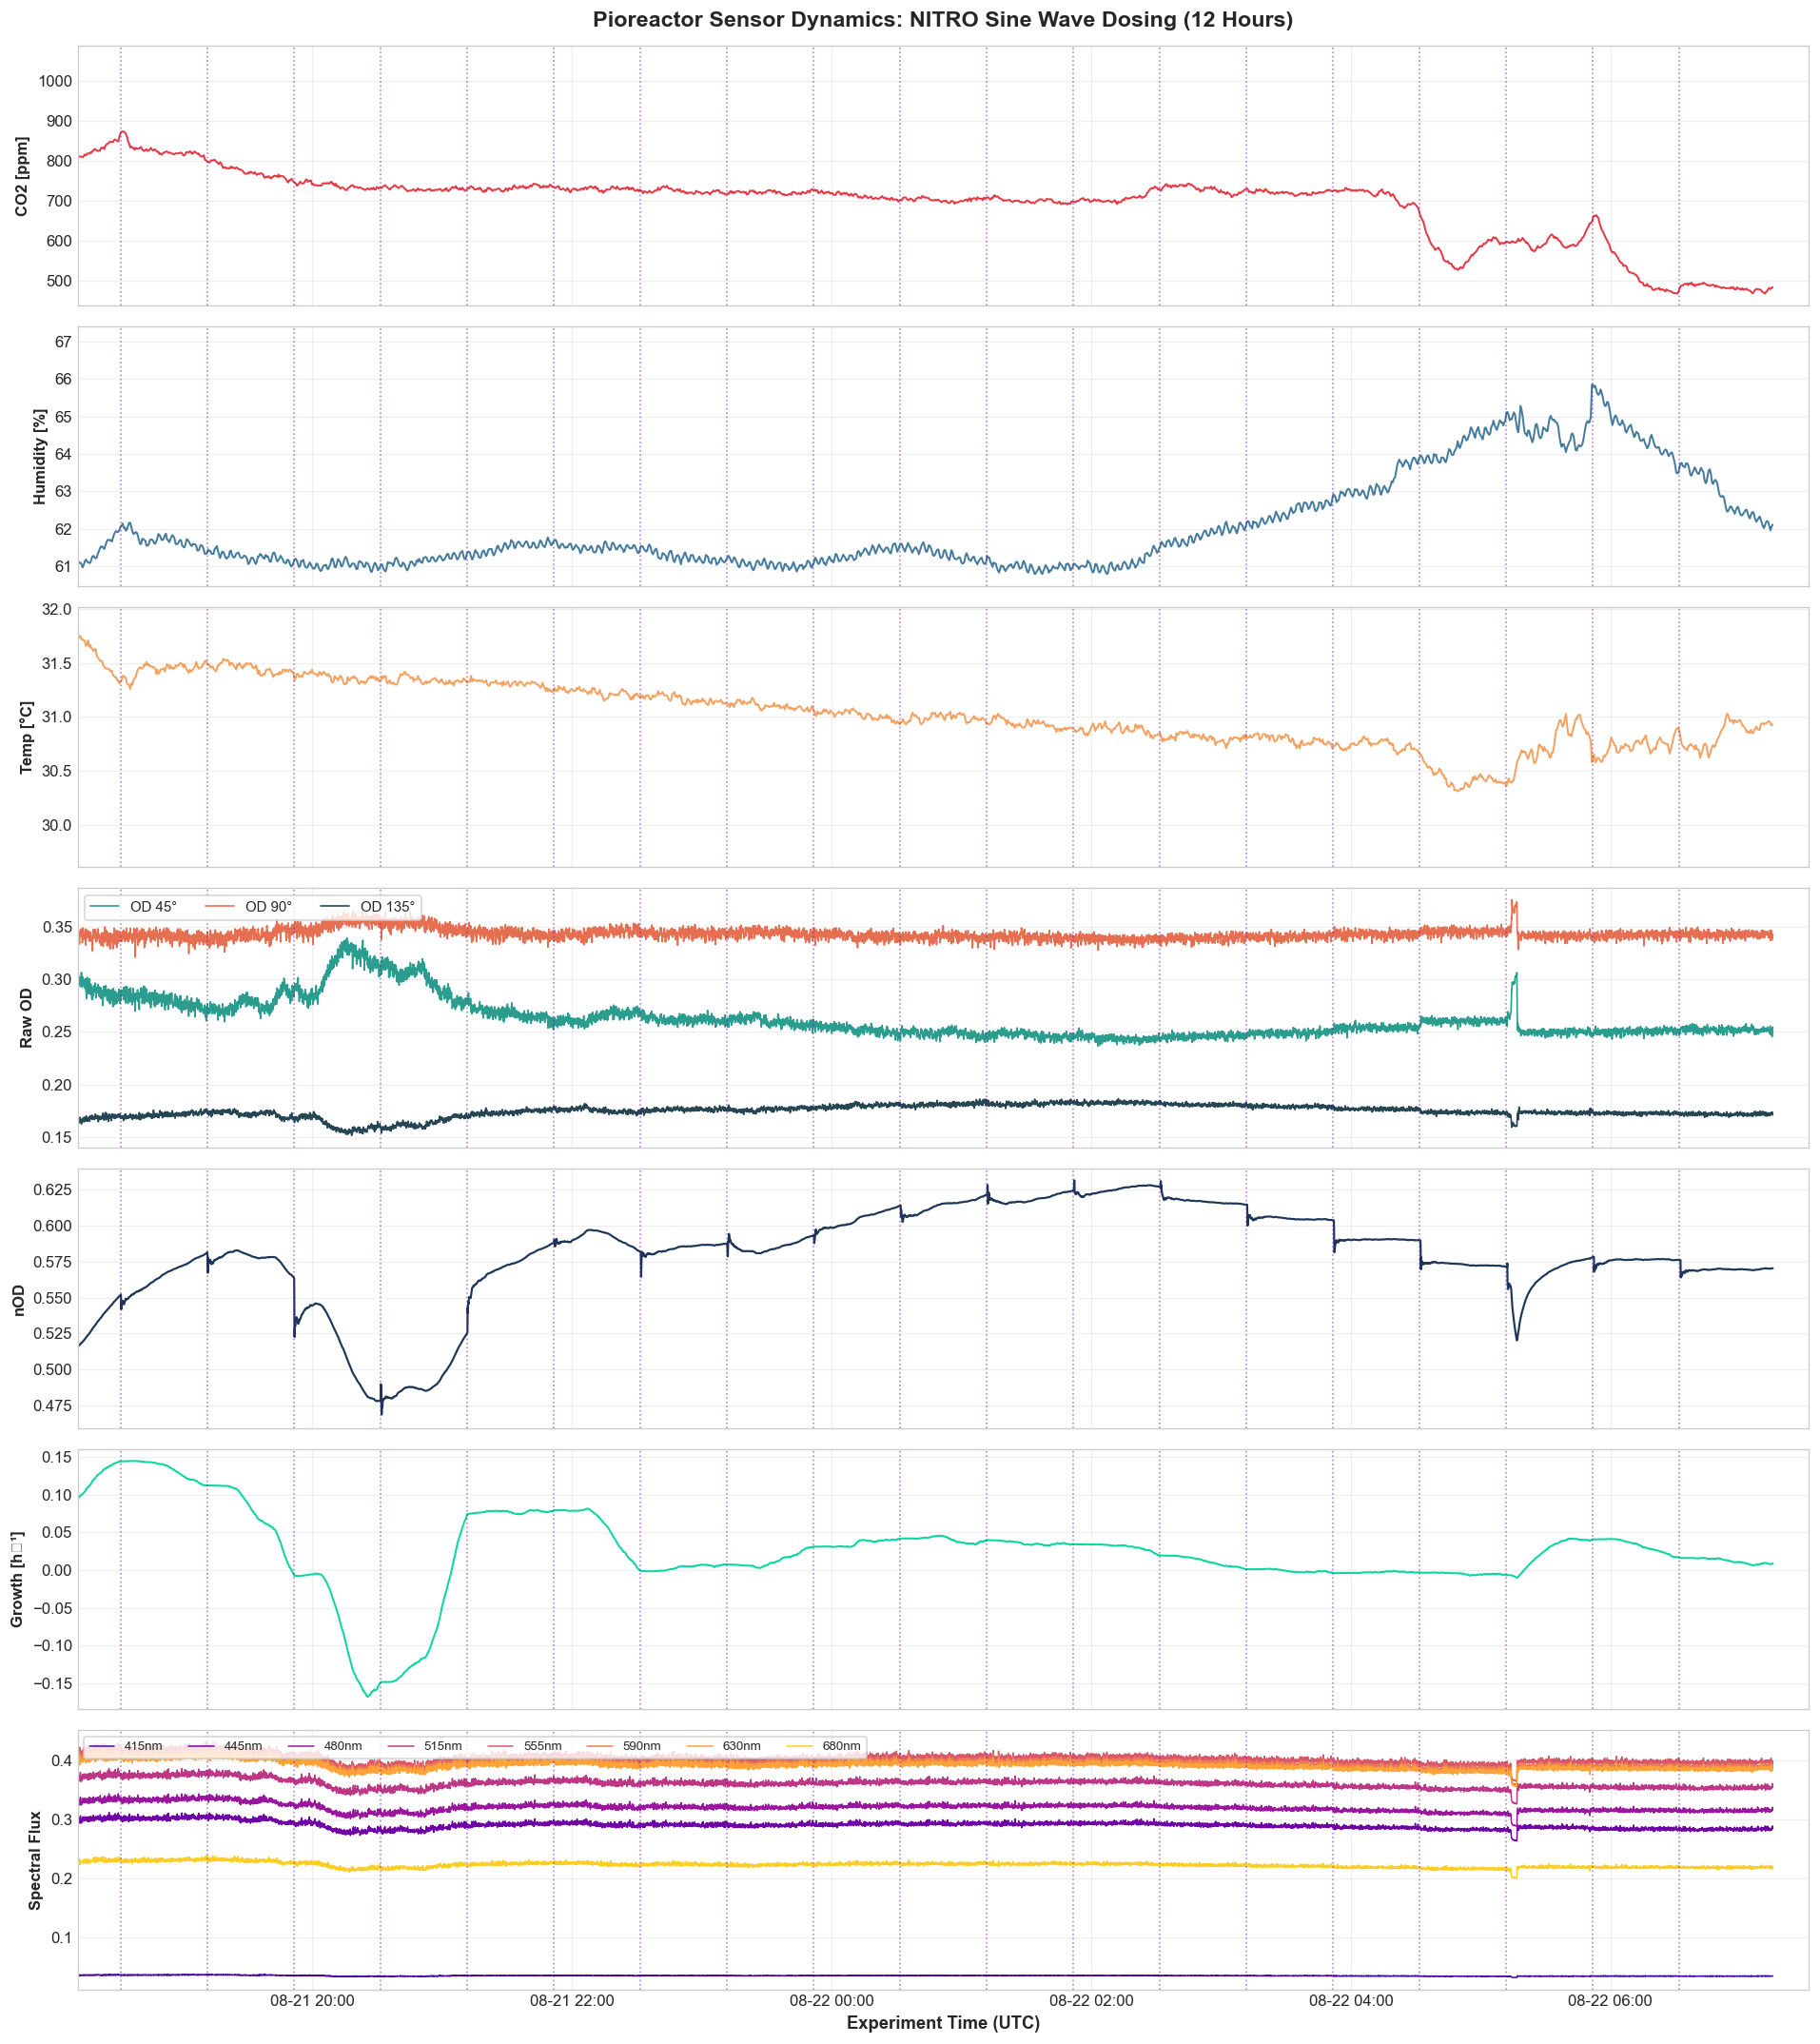

In [24]:
# Pivot OD and Spectrometer readings
df_od['dt_sec'] = df_od['timestamp'].dt.floor('s')
df_od_piv = df_od.pivot_table(index='dt_sec', columns='angle', values='od_reading', aggfunc='mean')
df_od_piv.columns = [f'OD_{col}' for col in df_od_piv.columns]

df_spec['dt_sec'] = df_spec['timestamp'].dt.floor('s')
df_spec_piv = df_spec.pivot_table(index='dt_sec', columns='band', values='reading', aggfunc='mean')
df_spec_piv.columns = [f'nm_{col}' for col in df_spec_piv.columns]

fig, axes = plt.subplots(7, 1, figsize=(16, 18), sharex=True)

# 1. CO2
axes[0].plot(df_co2['timestamp'], df_co2['co2_reading_ppm'], color='#e63946', lw=1.2)
axes[0].set_ylabel('CO2 [ppm]', fontweight='bold')
axes[0].set_title(f'Pioreactor Sensor Dynamics: {CHEM_NAME.upper()} Sine Wave Dosing (12 Hours)', fontsize=14, fontweight='bold', pad=12)

# 2. Relative Humidity
axes[1].plot(df_co2['timestamp'], df_co2['relative_humidity'], color='#457b9d', lw=1.2)
axes[1].set_ylabel('Humidity [%]', fontweight='bold')

# 3. Temperature
axes[2].plot(df_co2['timestamp'], df_co2['temperature_c'], color='#f4a261', lw=1.2)
axes[2].set_ylabel('Temp [°C]', fontweight='bold')

# 4. Optical Density (3 angles)
axes[3].plot(df_od_piv.index, df_od_piv['OD_45'], color='#2a9d8f', lw=1.0, label='OD 45°')
axes[3].plot(df_od_piv.index, df_od_piv['OD_90'], color='#e76f51', lw=1.0, label='OD 90°')
axes[3].plot(df_od_piv.index, df_od_piv['OD_135'], color='#264653', lw=1.0, label='OD 135°')
axes[3].set_ylabel('Raw OD', fontweight='bold')
axes[3].legend(loc='upper left', ncol=3, frameon=True, fontsize=9)

# 5. Normalized OD
axes[4].plot(df_od_filt['timestamp'], df_od_filt['normalized_od_reading'], color='#1d3557', lw=1.3)
axes[4].set_ylabel('nOD', fontweight='bold')

# 6. Growth Rate
axes[5].plot(df_growth['timestamp'], df_growth['rate'], color='#06d6a0', lw=1.2)
axes[5].set_ylabel('Growth [h⁻¹]', fontweight='bold')

# 7. Spectrometer 8 bands
spec_colors = cm.plasma(np.linspace(0.1, 0.9, 8))
for idx, band in enumerate([415, 445, 480, 515, 555, 590, 630, 680]):
    col = f'nm_{band}'
    if col in df_spec_piv.columns:
        axes[6].plot(df_spec_piv.index, df_spec_piv[col], color=spec_colors[idx], lw=0.9, label=f'{band}nm')
axes[6].set_ylabel('Spectral Flux', fontweight='bold')
axes[6].set_xlabel('Experiment Time (UTC)', fontweight='bold', fontsize=11)
axes[6].legend(loc='upper left', ncol=8, frameon=True, fontsize=8)

# Apply Dosing Pulses & Stirring Stall Warning Markers
for ax in axes:
    # Mark Dosing Events
    for cyc_idx, dose_val in enumerate(u):
        t_d = t0 + pd.Timedelta(minutes=cyc_idx * CYCLE_MIN)
        ax.axvline(t_d, color='#7209b7', ls=':', alpha=0.5, lw=1.0)
    
    # Mark Stirring Stalls if present
    for stall_t in stirring_stalls:
        ax.axvline(stall_t, color='red', ls='-', alpha=0.7, lw=1.5)
    
    ax.set_xlim(t0 - pd.Timedelta(minutes=20), t_end + pd.Timedelta(minutes=20))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
raw_plot_path = os.path.join(OUT_DIR, "raw_sensors_timeline.png")
plt.savefig(raw_plot_path, dpi=150)
print(f"Saved raw sensor plot to: {raw_plot_path}")
plt.show()

## Section 3 — Composite Multi-Sensor Overlay Plot

Saved composite overlay to: data/sine wave encoding/chem\nitro\results\composite_sensor_overlay.png


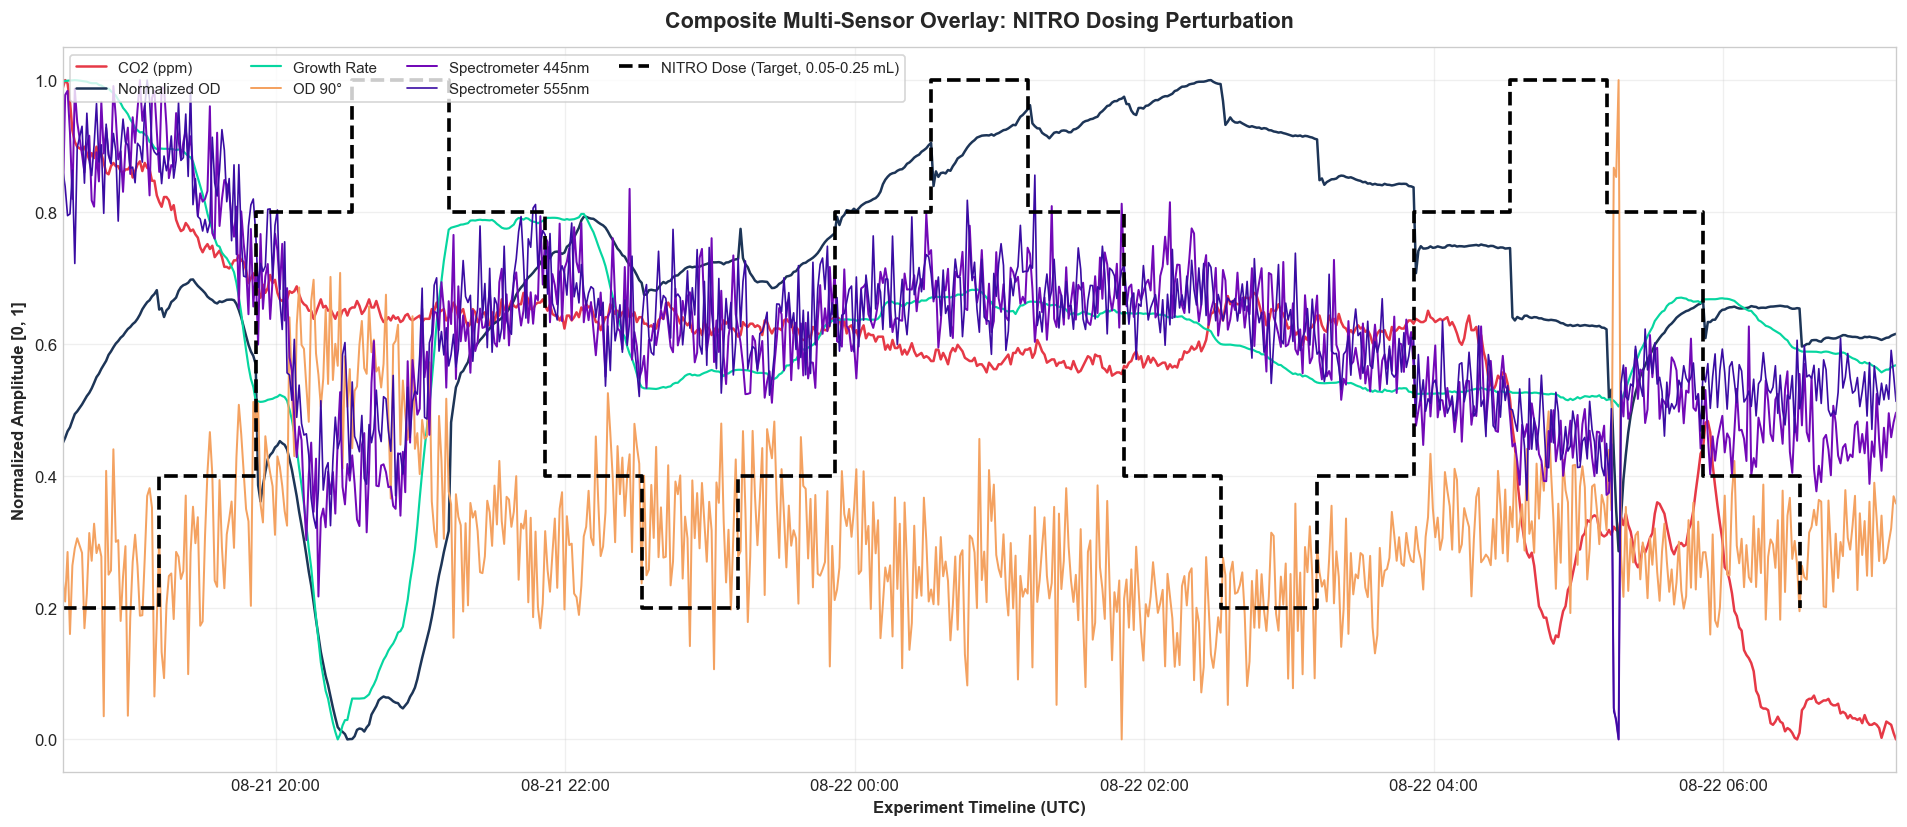

In [25]:
grid = pd.date_range(start=t0, end=t_end, freq='1min')
s_co2 = df_co2.set_index('timestamp')[['co2_reading_ppm', 'temperature_c', 'relative_humidity']].reindex(grid, method='nearest')
s_growth = df_growth.set_index('timestamp')[['rate']].reindex(grid, method='nearest')
s_od = df_od_piv.reindex(grid, method='nearest')
s_od_filt = df_od_filt.set_index('timestamp')[['normalized_od_reading']].reindex(grid, method='nearest')
s_spec = df_spec_piv.reindex(grid, method='nearest')

df_overlay = pd.concat([s_co2, s_growth, s_od, s_od_filt, s_spec], axis=1).dropna()
feat_cols = df_overlay.columns
df_norm = (df_overlay - df_overlay.min()) / (df_overlay.max() - df_overlay.min() + 1e-8)

plt.figure(figsize=(16, 7))
plt.plot(df_norm.index, df_norm['co2_reading_ppm'], label='CO2 (ppm)', color='#e63946', lw=1.5)
plt.plot(df_norm.index, df_norm['normalized_od_reading'], label='Normalized OD', color='#1d3557', lw=1.5)
plt.plot(df_norm.index, df_norm['rate'], label='Growth Rate', color='#06d6a0', lw=1.3)
plt.plot(df_norm.index, df_norm['OD_90'], label='OD 90°', color='#f4a261', lw=1.2)
plt.plot(df_norm.index, df_norm['nm_445'], label='Spectrometer 445nm', color='#7209b7', lw=1.2)
plt.plot(df_norm.index, df_norm['nm_555'], label='Spectrometer 555nm', color='#3a0ca3', lw=1.0)

# Step-like dose interpolation for visual overlay
dose_step_times = [t0 + pd.Timedelta(minutes=k * CYCLE_MIN) for k in range(total_cycles)]
plt.step(dose_step_times, u / 0.25, where='post', label=f'{CHEM_NAME.upper()} Dose (Target, 0.05-0.25 mL)', color='#000000', lw=2.2, ls='--')

# Highlight stirring errors if any
for stall_t in stirring_stalls:
    plt.axvline(stall_t, color='red', ls='-', alpha=0.7, lw=1.5, label='Stirring RPM 0' if stall_t == stirring_stalls[0] else "")

plt.title(f'Composite Multi-Sensor Overlay: {CHEM_NAME.upper()} Dosing Perturbation', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Experiment Timeline (UTC)', fontweight='bold')
plt.ylabel('Normalized Amplitude [0, 1]', fontweight='bold')
plt.xlim(t0, t_end)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.legend(loc='upper left', ncol=4, frameon=True, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()

overlay_plot_path = os.path.join(OUT_DIR, "composite_sensor_overlay.png")
plt.savefig(overlay_plot_path, dpi=150)
print(f"Saved composite overlay to: {overlay_plot_path}")
plt.show()

## Section 4 — Cycle-Mean Aggregation & 6-Cycle Baseline Decoupling

In [26]:
def get_cycle_mean(df, val_col, filter_col=None, filter_val=None):
    if df is None:
        return pd.Series(0, index=range(total_cycles))
    tmp = df.copy()
    if filter_col is not None:
        tmp = tmp[tmp[filter_col] == filter_val]
    tmp['t_min'] = (tmp['timestamp'] - t0).dt.total_seconds() / 60.0
    tmp = tmp[(tmp['t_min'] >= -20) & (tmp['t_min'] < (total_cycles + 1) * CYCLE_MIN)]
    tmp['cycle'] = np.round(tmp['t_min'] / CYCLE_MIN).astype(int)
    return (
        tmp.groupby('cycle')[val_col]
        .mean()
        .reindex(range(total_cycles))
        .interpolate(limit_direction='both')
    )

features = {}
features['OD_45'] = get_cycle_mean(df_od, 'od_reading', 'angle', 45)
features['OD_90'] = get_cycle_mean(df_od, 'od_reading', 'angle', 90)
features['OD_135'] = get_cycle_mean(df_od, 'od_reading', 'angle', 135)

for band in [415, 445, 480, 515, 555, 590, 630, 680]:
    features[f'nm_{band}'] = get_cycle_mean(df_spec, 'reading', 'band', band)

features['growth_rate'] = get_cycle_mean(df_growth, 'rate')
features['norm_od'] = get_cycle_mean(df_od_filt, 'normalized_od_reading')
features['co2_ppm'] = get_cycle_mean(df_co2, 'co2_reading_ppm')
features['temp_c'] = get_cycle_mean(df_co2, 'temperature_c')
features['humidity'] = get_cycle_mean(df_co2, 'relative_humidity')

df_cycles = pd.DataFrame(features).bfill().ffill()
sensor_names = list(df_cycles.columns)

# High-pass baseline subtraction (6-cycle / 4-hour wave period)
df_hp = df_cycles - df_cycles.rolling(window=6, min_periods=1, center=True).mean()
X_hp = df_hp.values

# Save cleaned state matrix to CSV
csv_out_path = os.path.join(OUT_DIR, "reservoir_state_matrix.csv")
df_hp_export = df_hp.copy()
df_hp_export['target_dose_ml'] = u
df_hp_export.to_csv(csv_out_path, index=False)
print(f"Saved reservoir state matrix to: {csv_out_path}")

Saved reservoir state matrix to: data/sine wave encoding/chem\nitro\results\reservoir_state_matrix.csv


## Section 5 — Feature Importance Ranking (Ridge Weights)

=== FEATURE IMPORTANCE RANKING (NITRO) ===
   1         OD_90      0.0440  ==============================
   2        OD_135      0.0280  ===================
   3        nm_480      0.0199  =============
   4        temp_c      0.0137  =========
   5      humidity      0.0113  =======
   6        nm_445      0.0105  =======
   7        nm_515      0.0077  =====
   8        nm_590      0.0075  =====
   9        nm_680      0.0070  ====
  10       norm_od      0.0059  ====
  11        nm_630      0.0047  ===
  12        nm_415      0.0027  =
  13        nm_555      0.0026  =
  14         OD_45      0.0024  =
  15   growth_rate      0.0023  =
  16       co2_ppm      0.0019  =

Top 4 Features: ['OD_90', 'OD_135', 'nm_480', 'temp_c']


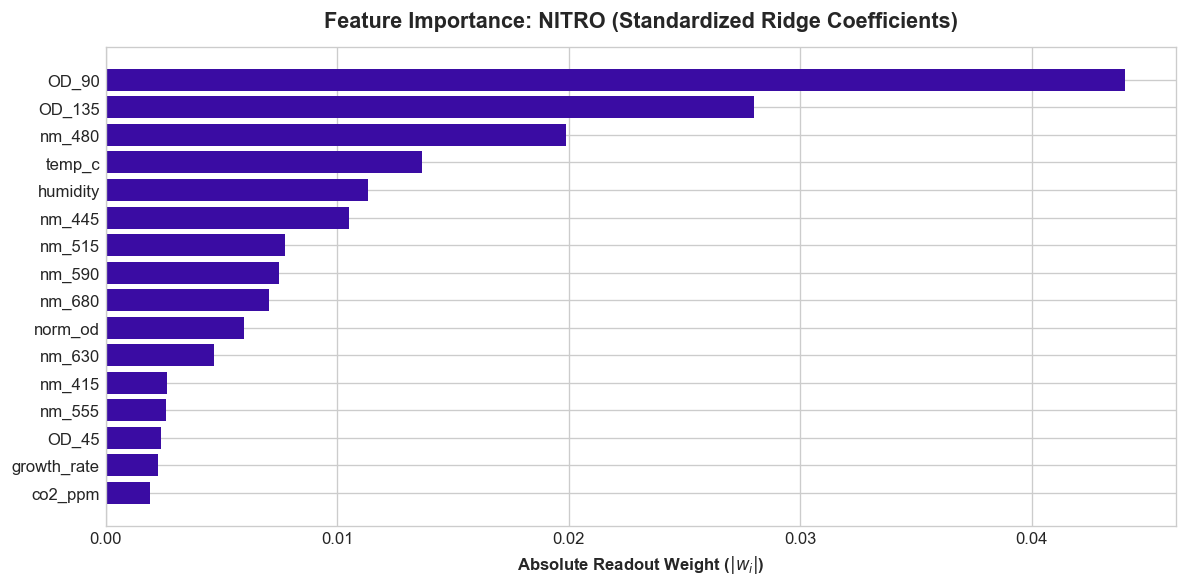

In [27]:
sc_fi = StandardScaler()
X_sc_fi = sc_fi.fit_transform(X_hp)
r_fi = Ridge(alpha=1.0)
r_fi.fit(X_sc_fi, u)

importance = np.abs(r_fi.coef_)
sorted_idx = np.argsort(importance)[::-1]

print(f"=== FEATURE IMPORTANCE RANKING ({CHEM_NAME.upper()}) ===")
for rank, i in enumerate(sorted_idx):
    bar = '=' * int(importance[i] * 30 / importance.max())
    print(f"  {rank+1:>2}  {sensor_names[i]:>12}  {importance[i]:>10.4f}  {bar}")

top4 = [sensor_names[i] for i in sorted_idx[:4]]
print(f"\nTop 4 Features: {top4}")

# Plot Feature Importance
plt.figure(figsize=(10, 5))
plt.barh(np.array(sensor_names)[sorted_idx][::-1], importance[sorted_idx][::-1], color='#3a0ca3')
plt.title(f'Feature Importance: {CHEM_NAME.upper()} (Standardized Ridge Coefficients)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Absolute Readout Weight ($|w_i|$)', fontweight='bold')
plt.tight_layout()
fi_plot_path = os.path.join(OUT_DIR, "feature_importance.png")
plt.savefig(fi_plot_path, dpi=150)
plt.show()

## Section 6 — Ridge Regression Multi-Configuration Benchmark

In [28]:
def delay_embed(X: np.ndarray, y: np.ndarray, delay: int):
    if delay == 0:
        return X.copy(), y.copy()
    rows = []
    for t in range(delay, len(X)):
        rows.append(np.concatenate([X[t - lag] for lag in range(delay + 1)]))
    return np.asarray(rows), y[delay:]

def ridge_loo(X: np.ndarray, y: np.ndarray):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    rcv = RidgeCV(alphas=ALPHAS, cv=None)
    rcv.fit(Xs, y)
    model = Ridge(alpha=rcv.alpha_)
    yp = cross_val_predict(model, Xs, y, cv=LeaveOneOut())
    nmse = mean_squared_error(y, yp) / np.var(y)
    mae = mean_absolute_error(y, yp)
    r2 = r2_score(y, yp)
    model.fit(Xs, y)
    return yp, nmse, mae, r2, model, scaler, rcv.alpha_

X_raw = df_cycles.values
X_top4 = df_hp[top4].values

configs = [
    ("A: Raw Levels (All 16, delay=0)", X_raw, 0),
    ("B: High-Pass (All 16, delay=0)",  X_hp,  0),
    ("C: High-Pass (Top 4, delay=0)",   X_top4, 0),
    ("D: High-Pass (All 16, delay=1)",  X_hp,  1),
    ("E: High-Pass (Top 4, delay=1)",   X_top4, 1),
    ("F: High-Pass (All 16, delay=2)",  X_hp,  2),
    ("G: High-Pass (All 16, delay=3)",  X_hp,  3),
]

print("=" * 75)
print(f"{'Configuration':<38}  {'NMSE':>8}  {'R2':>8}  {'Status'}")
print("=" * 75)

for label, X_mat, d in configs:
    Xd, yd = delay_embed(X_mat, u, d)
    yp, nmse, mae, r2, m, sc, alpha = ridge_loo(Xd, yd)
    status = ('EXCELLENT' if nmse < 0.2 else 'GOOD' if nmse < 0.5 else
              'OK' if nmse < 0.9 else 'above baseline')
    print(f"  {label:<36}  {nmse:>8.4f}  {r2:>8.4f}  [{status}]")
print("=" * 75)

Configuration                               NMSE        R2  Status
  A: Raw Levels (All 16, delay=0)         1.0160   -0.0160  [above baseline]
  B: High-Pass (All 16, delay=0)          0.8215    0.1785  [OK]
  C: High-Pass (Top 4, delay=0)           0.7247    0.2753  [OK]
  D: High-Pass (All 16, delay=1)          0.7869    0.2131  [OK]
  E: High-Pass (Top 4, delay=1)           0.8300    0.1700  [OK]
  F: High-Pass (All 16, delay=2)          0.6852    0.3148  [OK]
  G: High-Pass (All 16, delay=3)          0.5952    0.4048  [OK]


## Section 7 — Delay Embedding Sweep (Memory Depth $\tau$)

Saved delay sweep plot to: data/sine wave encoding/chem\nitro\results\delay_embedding_sweep.png


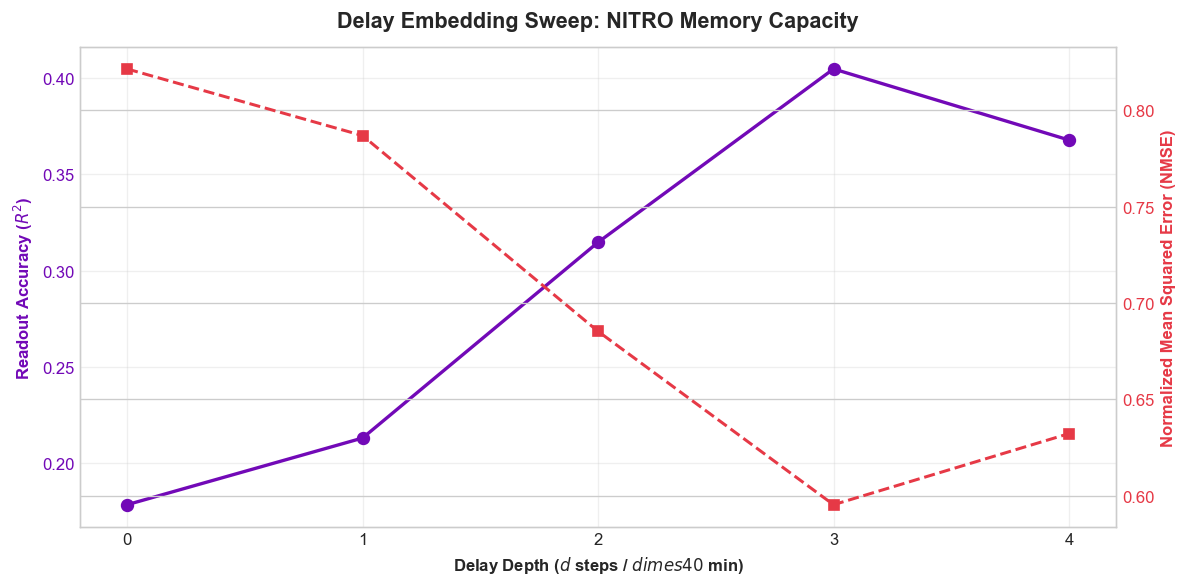

In [29]:
delays = range(0, 5)
sweep_rows = []

for d in delays:
    Xd, yd = delay_embed(X_hp, u, d)
    yp, nmse, mae, r2, m, sc, alpha = ridge_loo(Xd, yd)
    sweep_rows.append({
        'delay': d,
        'memory_min': d * CYCLE_MIN,
        'features': Xd.shape[1],
        'nmse': nmse,
        'r2': r2,
        'mae': mae,
        'alpha': alpha
    })

df_sweep = pd.DataFrame(sweep_rows)

fig, ax1 = plt.subplots(figsize=(10, 5))
color = '#7209b7'
ax1.set_xlabel(f'Delay Depth ($d$ steps / $d \times {int(CYCLE_MIN)}$ min)', fontweight='bold')
ax1.set_ylabel('Readout Accuracy ($R^2$)', color=color, fontweight='bold')
ax1.plot(df_sweep['delay'], df_sweep['r2'], color=color, marker='o', lw=2.0, ms=7, label='$R^2$')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(delays)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = '#e63946'
ax2.set_ylabel('Normalized Mean Squared Error (NMSE)', color=color, fontweight='bold')
ax2.plot(df_sweep['delay'], df_sweep['nmse'], color=color, marker='s', lw=1.8, ls='--', ms=6, label='NMSE')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Delay Embedding Sweep: {CHEM_NAME.upper()} Memory Capacity', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
sweep_plot_path = os.path.join(OUT_DIR, "delay_embedding_sweep.png")
plt.savefig(sweep_plot_path, dpi=150)
print(f"Saved delay sweep plot to: {sweep_plot_path}")
plt.show()

## Section 8 — Predicted vs Actual Sine Wave Reconstruction

Saved reconstruction plot to : data/sine wave encoding/chem\nitro\results\reconstructed_sine_wave.png
Saved prediction table to   : data/sine wave encoding/chem\nitro\results\readout_predictions.csv


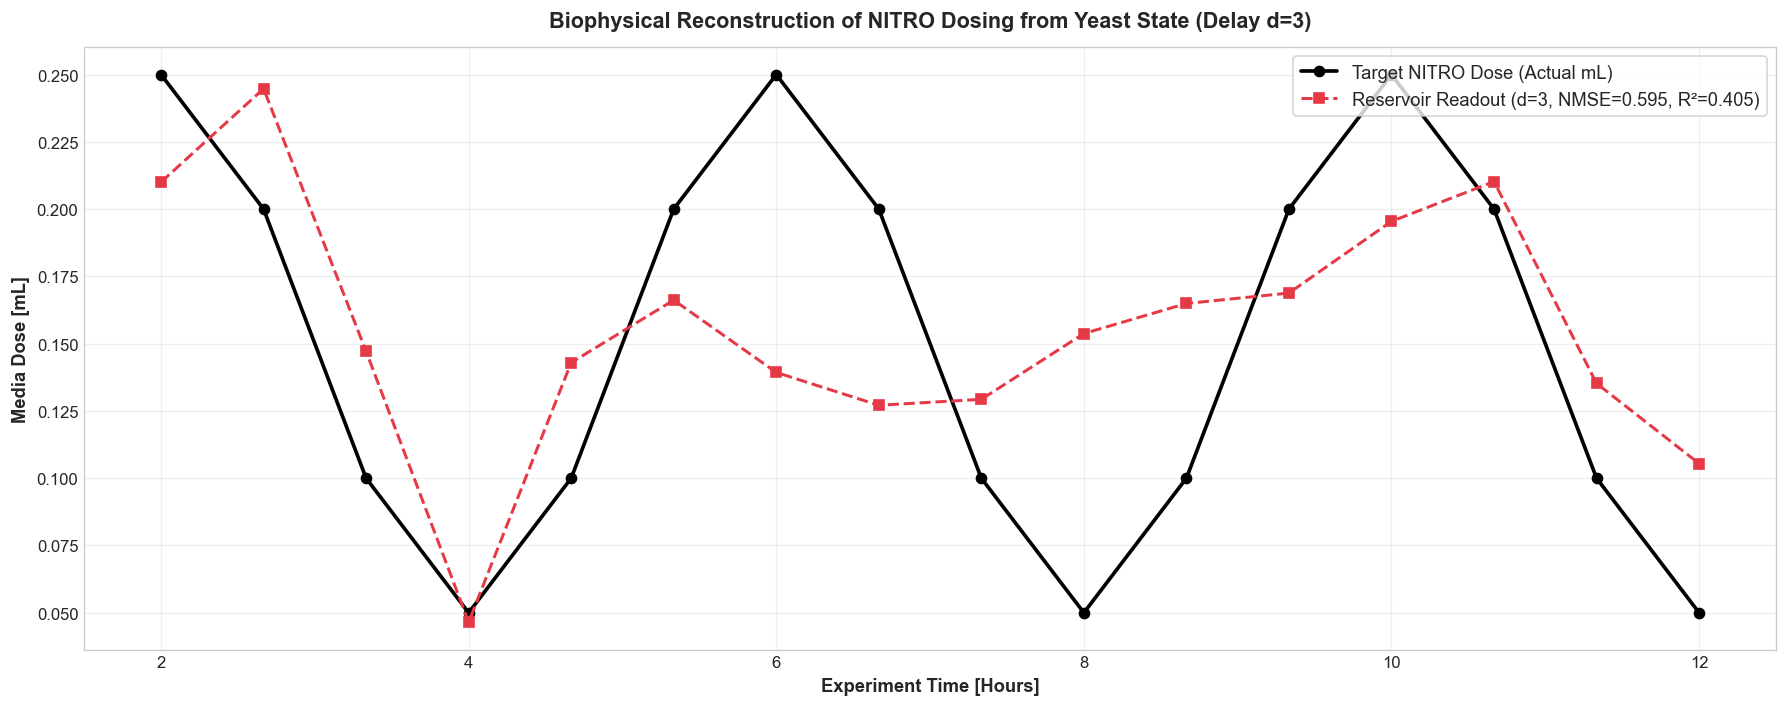

In [30]:
# Find best delay
best_delay = int(df_sweep.loc[df_sweep['r2'].idxmax(), 'delay'])
Xd_best, yd_best = delay_embed(X_hp, u, best_delay)
yp_best, nmse_b, mae_b, r2_b, m_b, sc_b, a_b = ridge_loo(Xd_best, yd_best)

cycles_idx = np.arange(best_delay + 1, len(u) + 1)
time_hrs = (cycles_idx - 1) * (CYCLE_MIN / 60.0)

plt.figure(figsize=(15, 6))
plt.plot(time_hrs, yd_best, label=f'Target {CHEM_NAME.upper()} Dose (Actual mL)', color='#000000', lw=2.2, marker='o', ms=6)
plt.plot(time_hrs, yp_best, label=f'Reservoir Readout (d={best_delay}, NMSE={nmse_b:.3f}, R²={r2_b:.3f})', color='#e63946', lw=1.8, ls='--', marker='s', ms=6)

plt.title(f'Biophysical Reconstruction of {CHEM_NAME.upper()} Dosing from Yeast State (Delay d={best_delay})', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Experiment Time [Hours]', fontweight='bold', fontsize=11)
plt.ylabel('Media Dose [mL]', fontweight='bold', fontsize=11)
plt.legend(loc='upper right', frameon=True, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

recon_plot_path = os.path.join(OUT_DIR, "reconstructed_sine_wave.png")
plt.savefig(recon_plot_path, dpi=150)

# Export prediction results to CSV
df_pred_export = pd.DataFrame({
    'cycle': cycles_idx,
    'time_hours': time_hrs,
    'target_dose_ml': yd_best,
    'predicted_dose_ml': yp_best
})
pred_csv_path = os.path.join(OUT_DIR, "readout_predictions.csv")
df_pred_export.to_csv(pred_csv_path, index=False)
print(f"Saved reconstruction plot to : {recon_plot_path}")
print(f"Saved prediction table to   : {pred_csv_path}")
plt.show()

## Section 9 — Multi-Chemical Batch Benchmark Comparison

Run this section to compute performance side-by-side across all 4 chemical sine wave datasets:

In [31]:
all_chems = ["glucose", "nitro", "salt", "sulfur"]
summary_records = []

for c in all_chems:
    c_folder = os.path.join(BASE_DIR, c)
    c_dosing = load_latest_csv(c_folder, "dosing_events-*.csv")
    c_od = load_latest_csv(c_folder, "od_readings-*.csv")
    c_od_filt = load_latest_csv(c_folder, "od_readings_filtered-*.csv")
    c_spec = load_latest_csv(c_folder, "as7341_spectrum_readings-*.csv")
    c_growth = load_latest_csv(c_folder, "growth_rates-*.csv")
    c_co2 = load_latest_csv(c_folder, "co2_readings-*.csv")
    
    c_manual = c_dosing[
        (c_dosing['source_of_event'] == 'dosing_automation:manual_dosing_control') &
        (c_dosing['event'] == 'add_media')
    ].copy()
    
    c_t0 = c_manual['timestamp'].min()
    c_manual['cycle'] = np.round((c_manual['timestamp'] - c_t0).dt.total_seconds() / (40.0 * 60.0)).astype(int)
    c_u = c_manual.groupby('cycle')['volume_change_ml'].sum().values
    c_tot = len(c_u)
    
    def c_cycle_mean(df, col, fcol=None, fval=None):
        if df is None: return pd.Series(0, index=range(c_tot))
        tmp = df.copy()
        if fcol is not None: tmp = tmp[tmp[fcol] == fval]
        tmp['t_min'] = (tmp['timestamp'] - c_t0).dt.total_seconds() / 60.0
        tmp = tmp[(tmp['t_min'] >= -20) & (tmp['t_min'] < (c_tot + 1) * 40.0)]
        tmp['cycle'] = np.round(tmp['t_min'] / 40.0).astype(int)
        return tmp.groupby('cycle')[col].mean().reindex(range(c_tot)).interpolate(limit_direction='both')
    
    c_feats = {}
    for a in [45, 90, 135]: c_feats[f'OD_{a}'] = c_cycle_mean(c_od, 'od_reading', 'angle', a)
    for b in [415, 445, 480, 515, 555, 590, 630, 680]: c_feats[f'nm_{b}'] = c_cycle_mean(c_spec, 'reading', 'band', b)
    c_feats['growth_rate'] = c_cycle_mean(c_growth, 'rate')
    c_feats['norm_od'] = c_cycle_mean(c_od_filt, 'normalized_od_reading')
    c_feats['co2_ppm'] = c_cycle_mean(c_co2, 'co2_reading_ppm')
    c_feats['temp_c'] = c_cycle_mean(c_co2, 'temperature_c')
    c_feats['humidity'] = c_cycle_mean(c_co2, 'relative_humidity')
    
    c_df = pd.DataFrame(c_feats).bfill().ffill()
    c_hp = c_df - c_df.rolling(window=6, min_periods=1, center=True).mean()
    
    # Test delay=0, 1, 2, 3
    for d in [0, 1, 2, 3]:
        Xd, yd = delay_embed(c_hp.values, c_u, d)
        yp, nmse, mae, r2, m, sc, a = ridge_loo(Xd, yd)
        summary_records.append({
            'Chemical': c.upper(),
            'Delay': d,
            'Memory_min': d * 40,
            'R2_score': r2,
            'NMSE': nmse,
            'MAE_mL': mae
        })

df_all_summary = pd.DataFrame(summary_records)
print("=" * 75)
print("  SIDE-BY-SIDE CHEMICAL RESERVOIR COMPUTING SUMMARY")
print("=" * 75)
print(df_all_summary.to_string(index=False))
print("=" * 75)

  SIDE-BY-SIDE CHEMICAL RESERVOIR COMPUTING SUMMARY
Chemical  Delay  Memory_min  R2_score     NMSE   MAE_mL
 GLUCOSE      0           0  0.439396 0.560604 0.041510
 GLUCOSE      1          40  0.918304 0.081696 0.014795
 GLUCOSE      2          80  0.903609 0.096391 0.019173
 GLUCOSE      3         120  0.951158 0.048842 0.013643
   NITRO      0           0  0.178518 0.821482 0.057487
   NITRO      1          40  0.213139 0.786861 0.050885
   NITRO      2          80  0.314767 0.685233 0.051889
   NITRO      3         120  0.404778 0.595222 0.048768
    SALT      0           0  0.330747 0.669253 0.047164
    SALT      1          40  0.605885 0.394115 0.040582
    SALT      2          80  0.537863 0.462137 0.043617
    SALT      3         120  0.559397 0.440603 0.041407
  SULFUR      0           0  0.330747 0.669253 0.047164
  SULFUR      1          40  0.605885 0.394115 0.040582
  SULFUR      2          80  0.537863 0.462137 0.043617
  SULFUR      3         120  0.559397 0.440603 0.041